# 01: Data Preprocessing and Description

This notebook covers the full data preparation pipeline:
1. **Loading** — read raw CSV with correct column types
2. **Cleaning** — remove impossible negative values, logical inconsistencies, insufficient firm coverage
3. **Consecutive years** — keep only observations that form consecutive year pairs
4. **Sample description** — firms by year, panel structure, missing years, firm status
5. **Industry classification** — assign firms to six broad industry groups
6. **Variable construction** — compute financial ratios from raw balance sheet and income statement
7. **Winsorization** — trim extreme values at P1/P99 and P5/P95
8. **Financial distress proxy** — construct composite indicator from three accounting criteria
9. **Criteria independence** — validate proxy using phi-coefficient

**Output:** `df_clean.csv` (full cleaned dataset with all variables) and `ana.csv` (analytical sample, 2019–2024)

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import itertools
from scipy.stats import chi2_contingency
from IPython.display import display

## **1. Load Data**
Read the raw CSV. Categorical columns are kept as strings; all other columns are transformed to numeric.

In [2]:
CATEGORICAL_COLS = [
    'Firm ID', 'Firm Status (Latest)', 'KVED',
    'Sector', 'Date Registration', 'Region'
]

df = pd.read_csv(
    'Final_YCM_ANONIMIZED_fin_data_2018-2024_BIG.csv',
    sep=';',
    encoding='utf-8',
    na_values=['NULL', 'null', 'NaN', '', '#VALUE!', '#REF!', '#DIV/0!'],
    dtype={col: str for col in CATEGORICAL_COLS},
    low_memory=False
)

# Convert all non-categorical columns to numeric
num_cols = [c for c in df.columns if c not in CATEGORICAL_COLS]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Loaded  : {len(df):,} obs | {df['Firm ID'].nunique():,} firms | {df.shape[1]} columns")

Loaded  : 84,301 obs | 18,621 firms | 167 columns


### Raw dataset preview

In [3]:
print("=" * 55)
print(f"COLUMNS IN RAW DATASET ({df.shape[1]} total)")
print("=" * 55)
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>3}. {col}")

COLUMNS IN RAW DATASET (167 total)
    1. Firm ID
    2. Firm Status (Latest)
    3. Year
    4. KVED
    5. Sector
    6. Date Registration
    7. Firm Age
    8. Region
    9. Number of Employees (Latest)
   10. Intangible Assets
   11. Cost (Gross Carrying Amount)
   12. Accumulated Depreciation
   13. Capital Work in Progress
   14. PPE
   15. Cost (Gross Carrying Amount).1
   16. Accumulated Depreciation.1
   17. Investment Property
   18. Cost (Gross Carrying Amount).2
   19. Accumulated Depreciation.2
   20. Non-Current Biological Assets
   21. Cost (Gross Carrying Amount).3
   22. Accumulated Depreciation.3
   23. Long-Term Financial Investments – Equity Method
   24. Other Financial Investments
   25. Non-Current Trade and Other Receivables
   26. Deferred Tax Assets
   27. Goodwill
   28. Deferred Acquisition Costs
   29. Balance in Centralized Insurance Reserve Funds
   30. Other Non-Current Assets
   31. Total Non-Current Assets
   32. Inventories
   33. Raw Materials and S

In [4]:
print(f"Shape: {df.shape}")

Shape: (84301, 167)


In [5]:
display(df.head(20))

,Firm ID,Firm Status (Latest),Year,KVED,Sector,Date Registration,Firm Age,Region,Number of Employees (Latest),Intangible Assets,...,Employee Benefits Expense (Wages and Salaries),Social Security Contributions,Depreciation,Other Operating Expenses (by nature),Total Operating Expenses,Weighted Average Number of Ordinary Shares,Diluted Weighted Average Number of Ordinary Shares,Basic Earnings (Loss) per Share,Diluted Earnings (Loss) per Share,Dividends per Ordinary Share
0,1,Припинено,2018,20.14,C,08.12.2003,16,Чернівецька область,0,0,...,154.0,26.0,105.0,456.0,748.0,0.0,0.0,0.0,0.0,0.0
1,1,Припинено,2019,20.14,C,08.12.2003,17,Чернівецька область,0,0,...,195.0,35.0,105.0,228.0,571.0,0.0,0.0,0.0,0.0,0.0
2,1,Припинено,2021,20.14,C,08.12.2003,19,Чернівецька область,0,0,...,410.0,72.0,90.0,947.0,1529.0,0.0,0.0,0.0,0.0,0.0
3,1,Припинено,2022,20.14,C,08.12.2003,20,Чернівецька область,0,0,...,405.0,87.0,87.0,1874.0,2456.0,0.0,0.0,0.0,0.0,0.0
4,1,Припинено,2023,20.14,C,08.12.2003,21,Чернівецька область,0,0,...,419.0,92.0,34.0,3882.0,4432.0,0.0,0.0,0.0,0.0,0.0
5,2,Не перебуває в процесі припинення,2023,01.46,A,06.09.1994,30,Львівська область,214,0,...,15643.0,3472.0,25568.0,65079.0,415358.0,0.0,0.0,0.0,0.0,0.0
6,2,Не перебуває в процесі припинення,2024,01.46,A,06.09.1994,31,Львівська область,214,0,...,39686.0,8707.0,37187.0,142440.0,1123592.0,0.0,0.0,0.0,0.0,0.0
7,3,В стані припинення,2020,02.40,A,29.03.1999,22,Харківська область,0,26,...,23982.0,5315.0,2403.0,2337.0,59121.0,0.0,0.0,0.0,0.0,0.0
8,3,В стані припинення,2021,02.40,A,29.03.1999,23,Харківська область,0,3,...,19529.0,4242.0,2319.0,7833.0,62279.0,0.0,0.0,0.0,0.0,0.0
9,3,В стані припинення,2022,02.40,A,29.03.1999,24,Харківська область,0,0,...,22574.0,4763.0,2239.0,7334.0,63495.0,0.0,0.0,0.0,0.0,0.0


## **2. Data Cleaning**

### 2.1 Missing values

In [6]:
miss = pd.DataFrame({
    'N missing': df.isna().sum(),
    '% missing': (df.isna().mean() * 100).round(1),
    'N present': df.notna().sum(),
}).sort_values('% missing', ascending=False)

miss_only = miss[miss['N missing'] > 0]

print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(miss_only.to_string())

MISSING VALUES
                                                    N missing  % missing  N present
Basic Earnings (Loss) per Share                          5149        6.1      79152
Diluted Earnings (Loss) per Share                        4700        5.6      79601
Dividends per Ordinary Share                              150        0.2      84151
COGS                                                       51        0.1      84250
Net Revenue                                                52        0.1      84249
Total Current Liabilities                                   3        0.0      84298
Total Liabilities                                           3        0.0      84298
Total Liabilities and Equity                                2        0.0      84299
Net Claims Incurred                                        14        0.0      84287
Gross Profit                                                5        0.0      84296
Current Provisions                                          3

### 2.2 Impossible negative values
These variables cannot be negative by definition. A negative value means there is an error in the data.

In [7]:
ALWAYS_POSITIVE = [
    # Assets
    'PPE', 'Total Non-Current Assets', 'Inventories', 'Accounts Receivable',
    'Cash and Cash Equivalents', 'Cash', 'Total Current Assets', 'Total Assets',
    # Liabilities
    'Long-Term Bank Loans', 'Total Long-term Liabilities', 'Short-Term Bank Loans',
    'Total Debt', 'Accounts Payable', 'Total Current Liabilities',
    'Total Liabilities', 'Total Liabilities and Equity',
    # P&L
    'Net Revenue', 'COGS', 'Financial Expenses', 'Depreciation',
    # Firm characteristics
    'Number of Employees', 'Firm Age',
]
ALWAYS_POSITIVE = [c for c in ALWAYS_POSITIVE if c in df.columns]

print("=" * 50)
print("IMPOSSIBLE NEGATIVE VALUES")
print("=" * 50)
print(f"{'Variable':<50} {'N negative':>10}  {'% negative':>10}")
print()
found_any = False
for col in ALWAYS_POSITIVE:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print(f"{col:<50} {n_neg:>10,}  {n_neg/len(df)*100:>9.2f}%")
        found_any = True
if not found_any:
    print("No impossible negative values found.")

IMPOSSIBLE NEGATIVE VALUES
Variable                                           N negative  % negative

PPE                                                         8       0.01%
Total Non-Current Assets                                    2       0.00%
Accounts Receivable                                        16       0.02%
Cash and Cash Equivalents                                  38       0.05%
Long-Term Bank Loans                                        3       0.00%
Total Long-term Liabilities                                22       0.03%
Short-Term Bank Loans                                       5       0.01%
Total Debt                                                  7       0.01%
Accounts Payable                                            1       0.00%
Total Current Liabilities                                   4       0.00%
Total Liabilities                                           4       0.00%
Net Revenue                                                30       0.04%
COGS      

### 2.3 Logical consistency checks
Verify fundamental accounting identities. Flagged observations are removed in the next step.

In [8]:
checks = []

# Balance sheet identity checks
c = df[['Total Assets', 'Total Non-Current Assets', 'Total Current Assets']].dropna()
diff = (c['Total Assets'] - c['Total Non-Current Assets'] - c['Total Current Assets']).abs()
checks.append(('Total Assets ≠ Non-Current + Current Assets', (diff > 1).sum(), len(c)))

c = df[['Total Liabilities and Equity', 'Total Equity',
        'Total Long-term Liabilities', 'Total Current Liabilities']].dropna()
diff = (c['Total Liabilities and Equity'] - c['Total Equity']
        - c['Total Long-term Liabilities'] - c['Total Current Liabilities']).abs()
checks.append(('Total L&E ≠ Equity + LT Liabilities + ST Liabilities', (diff > 1).sum(), len(c)))

c = df[['Total Assets', 'Total Liabilities and Equity']].dropna()
checks.append(('Total Assets ≠ Total Liabilities and Equity',
               (c['Total Assets'] - c['Total Liabilities and Equity']).abs().gt(1).sum(), len(c)))

c = df[['Total Assets', 'Total Current Assets']].dropna()
checks.append(('Total Assets < Total Current Assets', (c['Total Assets'] < c['Total Current Assets']).sum(), len(c)))

c = df[['Total Assets', 'Total Non-Current Assets']].dropna()
checks.append(('Total Assets < Total Non-Current Assets', (c['Total Assets'] < c['Total Non-Current Assets']).sum(), len(c)))

c = df[['Total Liabilities', 'Total Assets', 'Total Equity']].dropna()
diff = (c['Total Liabilities'] - (c['Total Assets'] - c['Total Equity'])).abs()
checks.append(('Total Liabilities ≠ Total Assets - Total Equity', (diff > 1).sum(), len(c)))

c = df[['Total Debt', 'Short-Term Bank Loans']].dropna()
checks.append(('Total Debt < Short-Term Bank Loans', (c['Total Debt'] < c['Short-Term Bank Loans']).sum(), len(c)))

c = df[['Total Debt', 'Long-Term Bank Loans']].dropna()
checks.append(('Total Debt < Long-Term Bank Loans', (c['Total Debt'] < c['Long-Term Bank Loans']).sum(), len(c)))

c = df[['EBITDA', 'EBIT']].dropna()
checks.append(('EBITDA < EBIT', (c['EBITDA'] < c['EBIT']).sum(), len(c)))

c = df[['Total Liabilities', 'Total Current Liabilities']].dropna()
checks.append(('Total Liabilities < Total Current Liabilities',
               (c['Total Liabilities'] < c['Total Current Liabilities']).sum(), len(c)))

c = df[['Total Liabilities', 'Total Long-term Liabilities']].dropna()
checks.append(('Total Liabilities < Total Long-term Liabilities',
               (c['Total Liabilities'] < c['Total Long-term Liabilities']).sum(), len(c)))

print("=" * 70)
print("LOGICAL CONSISTENCY CHECKS")
print("=" * 70)
print(f"{'Check':<52} {'Failed':>11}  {'%':>6}  {'N obs':>8}")
print()
for label, n_fail, n_total in checks:
    status = '✓' if n_fail == 0 else '⚠'
    pct = n_fail / n_total * 100 if n_total > 0 else 0
    print(f"{status}  {label:<52} {n_fail:>8,}  {pct:>5.2f}%  {n_total:>8,}")

LOGICAL CONSISTENCY CHECKS
Check                                                     Failed       %     N obs

✓  Total Assets ≠ Non-Current + Current Assets                 0   0.00%    84,299
✓  Total L&E ≠ Equity + LT Liabilities + ST Liabilities        0   0.00%    84,298
✓  Total Assets ≠ Total Liabilities and Equity                 0   0.00%    84,299
⚠  Total Assets < Total Current Assets                         2   0.00%    84,299
✓  Total Assets < Total Non-Current Assets                     0   0.00%    84,299
✓  Total Liabilities ≠ Total Assets - Total Equity             0   0.00%    84,298
⚠  Total Debt < Short-Term Bank Loans                          3   0.00%    84,301
⚠  Total Debt < Long-Term Bank Loans                           5   0.01%    84,301
⚠  EBITDA < EBIT                                              18   0.02%    84,289
⚠  Total Liabilities < Total Current Liabilities              22   0.03%    84,298
⚠  Total Liabilities < Total Long-term Liabilities         

### 2.4 Minimum observations per firm

In [9]:
obs_count = df.groupby('Firm ID')['Year'].count()
single_obs = obs_count[obs_count < 2]

print("=" * 50)
print("MINIMUM OBSERVATIONS PER FIRM")
print("=" * 50)
print(f"Total firms           : {len(obs_count):,}")
print(f"Firms with only 1 obs : {len(single_obs):,}")
print(f"Firms with ≥ 2 obs    : {(obs_count >= 2).sum():,}")

MINIMUM OBSERVATIONS PER FIRM
Total firms           : 18,621
Firms with only 1 obs : 0
Firms with ≥ 2 obs    : 18,621


### 2.5 Apply all filters and print cleaning summary

In [10]:
n_before, firms_before = len(df), df['Firm ID'].nunique()

# ── Filter 1: impossible negative values ──
bad_neg = pd.Series(False, index=df.index)
for col in ALWAYS_POSITIVE:
    bad_neg |= (df[col] < 0)
n_neg = bad_neg.sum()
df = df[~bad_neg].copy()

# ── Filter 2: logical inconsistencies ──
bad_logic = (
    (df['Total Assets'] < df['Total Current Assets']) |
    (df['Total Debt'] < df['Short-Term Bank Loans']) |
    (df['Total Debt'] < df['Long-Term Bank Loans']) |
    (df['EBITDA'] < df['EBIT']) |
    (df['Total Liabilities'] < df['Total Current Liabilities']) |
    (df['Total Liabilities'] < df['Total Long-term Liabilities'])
)
n_logic = bad_logic.sum()
df = df[~bad_logic].copy()

# ── Filter 3: firms with only 1 obs ──
def drop_single_obs_firms(df):
    obs = df.groupby('Firm ID')['Year'].count()
    return df[~df['Firm ID'].isin(obs[obs < 2].index)].copy()

obs_count = df.groupby('Firm ID')['Year'].count()
single_firms = obs_count[obs_count < 2].index
n_single = len(single_firms)
df = drop_single_obs_firms(df)

# ── Second pass: firms that became single-obs after removal ──
obs_count_after = df.groupby('Firm ID')['Year'].count()
new_single_firms = obs_count_after[obs_count_after < 2].index
n_new_single = len(new_single_firms)
df = drop_single_obs_firms(df)

print("=" * 50)
print("CLEANING SUMMARY")
print("=" * 50)
print(f"Obs removed total  : {n_before - len(df):,}")
print(f"Obs remaining      : {len(df):,}  (was {n_before:,})")
print(f"Firms remaining    : {df['Firm ID'].nunique():,}  (was {firms_before:,})")

CLEANING SUMMARY
Obs removed total  : 190
Obs remaining      : 84,111  (was 84,301)
Firms remaining    : 18,602  (was 18,621)


## **3. Consecutive Year Filter**
Keep only observations that form at least one consecutive year-pair with a neighbour. Isolated observations are dropped.

In [11]:
# Sort before applying lag-based logic
df_clean = df.sort_values(['Firm ID', 'Year']).copy()

# ── Identify consecutive pairs ──
df_clean['Year_prev'] = df_clean.groupby('Firm ID')['Year'].shift(1)
df_clean['Year_Gap']  = df_clean['Year'] - df_clean['Year_prev']
df_clean['Gap_next']  = df_clean.groupby('Firm ID')['Year_Gap'].shift(-1)

# A row is kept if it is consecutive with the previous OR with the next observation
df_clean['Keep'] = (df_clean['Year_Gap'] == 1) | (df_clean['Gap_next'] == 1)

n_before_consec = len(df_clean)
firms_before_consec = df_clean['Firm ID'].nunique()

df_clean = df_clean[df_clean['Keep']].copy()
df_clean = df_clean.drop(columns=['Year_prev', 'Year_Gap', 'Gap_next', 'Keep'])

# Drop firms that now have only 1 observation
df_clean = drop_single_obs_firms(df_clean)

print("=" * 50)
print("CONSECUTIVE YEARS")
print("=" * 50)
print(f"Full dataset       : {n_before_consec:,} obs | {firms_before_consec:,} firms")
print(f"Consecutive years  : {len(df_clean):,} obs | {df_clean['Firm ID'].nunique():,} firms")
print(f"Dropped            : {n_before_consec - len(df_clean):,} obs")

CONSECUTIVE YEARS
Full dataset       : 84,111 obs | 18,602 firms
Consecutive years  : 81,269 obs | 18,183 firms
Dropped            : 2,842 obs


## **4. Sample Description**

### 4.1 Overall summary

In [12]:
total_obs   = len(df_clean)
total_firms = df_clean['Firm ID'].nunique()
years       = sorted(df_clean['Year'].dropna().astype(int).unique())

print("=" * 50)
print("SAMPLE DESCRIPTION")
print("=" * 50)
print(f"  Total observations : {total_obs:,}")
print(f"  Unique firms       : {total_firms:,}")
print(f"  Years              : {years[0]} – {years[-1]}  ({len(years)} years)")
print(f"  Total columns      : {df_clean.shape[1]}")

SAMPLE DESCRIPTION
  Total observations : 81,269
  Unique firms       : 18,183
  Years              : 2018 – 2024  (7 years)
  Total columns      : 167


### 4.2 Firms by year

In [13]:
yearly = (
    df_clean.groupby('Year')
    .agg(
        Unique_Firms = ('Firm ID', 'nunique'),
        Observations = ('Firm ID', 'count'),
        Share_pct    = ('Firm ID', lambda x: round(x.nunique() / total_firms * 100, 1))
    )
)
yearly.index = yearly.index.astype(int)
yearly.columns = ['Unique Firms', 'Observations', 'Share of Total Firms (%)']

print("=" * 50)
print("FIRMS BY YEAR")
print("=" * 50)
print(yearly.to_string())

FIRMS BY YEAR
      Unique Firms  Observations  Share of Total Firms (%)
Year                                                      
2018         10918         10918                      60.0
2019         12528         12528                      68.9
2020         10673         10673                      58.7
2021         12635         12635                      69.5
2022         12117         12117                      66.6
2023         11900         11900                      65.4
2024         10498         10498                      57.7


### 4.3 Panel structure: firms by number of years observed

In [14]:
df_s = df_clean.sort_values(['Firm ID', 'Year']).copy()
obs_per_firm = df_s.groupby('Firm ID')['Year'].count()

def is_consecutive(years):
    y = sorted(years)
    return all(y[i+1] - y[i] == 1 for i in range(len(y) - 1))

firm_years       = df_s.groupby('Firm ID')['Year'].apply(list)
firm_consecutive = firm_years.apply(is_consecutive)

result = (
    pd.DataFrame({'N_years': obs_per_firm, 'Consecutive': firm_consecutive})
    .groupby('N_years')
    .agg(Total_Firms=('Consecutive', 'count'), Consecutive_Firms=('Consecutive', 'sum'))
    .assign(
        Non_Consecutive  = lambda x: x['Total_Firms'] - x['Consecutive_Firms'],
        Pct_Consecutive  = lambda x: (x['Consecutive_Firms'] / x['Total_Firms'] * 100).round(1),
        Pct_of_All_Firms = lambda x: (x['Total_Firms'] / total_firms * 100).round(1),
    )
)
result.index.name = 'Years of Data'
result.columns = ['Total Firms', 'Consecutive', 'Non-Consecutive', 'Consecutive (%)', 'Share of All Firms (%)']

print("=" * 60)
print("PANEL STRUCTURE: FIRMS BY NUMBER OF YEARS")
print("=" * 60)
print(result.to_string())
print()
print(f"Total firms                : {total_firms:,}")
print(f"Firms with all 7 years     : {(obs_per_firm == 7).sum():,}  ({(obs_per_firm == 7).sum() / total_firms * 100:.1f}%)")
print(f"Firms fully consecutive    : {firm_consecutive.sum():,}  ({firm_consecutive.sum() / total_firms * 100:.1f}%)")
print(f"Firms with gaps (any)      : {(~firm_consecutive).sum():,}  ({(~firm_consecutive).sum() / total_firms * 100:.1f}%)")

PANEL STRUCTURE: FIRMS BY NUMBER OF YEARS
               Total Firms  Consecutive  Non-Consecutive  Consecutive (%)  Share of All Firms (%)
Years of Data                                                                                    
2                     3949         3949                0            100.0                    21.7
3                     2589         2589                0            100.0                    14.2
4                     2842         2504              338             88.1                    15.6
5                     2179         1880              299             86.3                    12.0
6                     3027         1231             1796             40.7                    16.6
7                     3597         3597                0            100.0                    19.8

Total firms                : 18,183
Firms with all 7 years     : 3,597  (19.8%)
Firms fully consecutive    : 15,750  (86.6%)
Firms with gaps (any)      : 2,433  (13.4%)


### 4.4 Missing years distribution

In [15]:
firm_years_present = df_clean.groupby('Firm ID')['Year'].apply(set)
firm_first = df_clean.groupby('Firm ID')['Year'].min()
firm_last  = df_clean.groupby('Firm ID')['Year'].max()

missing_years = []
for firm_id, years_present in firm_years_present.items():
    first    = int(firm_first[firm_id])
    last     = int(firm_last[firm_id])
    expected = set(range(first, last + 1))
    missing  = expected - {int(y) for y in years_present}
    for y in missing:
        missing_years.append({'Firm ID': firm_id, 'Missing Year': y})

df_missing = pd.DataFrame(missing_years)

print("=" * 50)
print("MISSING YEARS DISTRIBUTION")
print("=" * 50)
if len(df_missing) > 0:
    print(df_missing['Missing Year'].value_counts().sort_index()
          .rename('Firms with gap in this year').to_string())
else:
    print("No missing years found.")

MISSING YEARS DISTRIBUTION
Missing Year
2020    1957
2021     389
2022     397


### 4.5 Firms by legal status

In [16]:
STATUS_MAP = {
    'Не перебуває в процесі припинення'        : 'Active',
    'В стані припинення'                        : 'In liquidation',
    'Припинено'                                 : 'Liquidated',
    'Порушено справу про банкрутство'           : 'Bankruptcy proceedings',
    'Порушено справу про банкрутство (санація)' : 'Bankruptcy (restructuring)',
}

firm_status = (
    df_clean.groupby('Firm Status (Latest)', dropna=False)['Firm ID']
    .nunique().reset_index()
    .rename(columns={'Firm ID': 'Unique Firms', 'Firm Status (Latest)': 'Status'})
    .sort_values('Unique Firms', ascending=False)
)
firm_status['Status']    = firm_status['Status'].replace(STATUS_MAP)
firm_status['Share (%)'] = (firm_status['Unique Firms'] / firm_status['Unique Firms'].sum() * 100).round(1)

print("=" * 50)
print("FIRMS BY STATUS")
print("=" * 50)
print(firm_status.to_string(index=False))

FIRMS BY STATUS
                    Status  Unique Firms  Share (%)
                    Active         16491       90.7
            In liquidation           799        4.4
                Liquidated           731        4.0
    Bankruptcy proceedings           126        0.7
Bankruptcy (restructuring)            36        0.2


## **5. Industry Classification**
Firms are assigned to six industry groups based on KVED sector codes. Sector C (manufacturing) is split into light and heavy industry using 2-digit KVED codes.

### 5.1 Firms by raw KVED sector

In [17]:
sector_summary = (
    df_clean.groupby('Sector')
    .agg(
        Unique_Firms = ('Firm ID', 'nunique'),
        Observations = ('Firm ID', 'count'),
    )
    .assign(
        Share_Firms_pct = lambda x: (x['Unique_Firms'] / total_firms * 100).round(1),
        Share_Obs_pct   = lambda x: (x['Observations'] / total_obs * 100).round(1),
    )
    .sort_values('Unique_Firms', ascending=False)
)
sector_summary.columns = ['Unique Firms', 'Observations', 'Share of Firms (%)', 'Share of Obs (%)']

print("=" * 50)
print("FIRMS BY SECTOR")
print("=" * 50)
print(sector_summary.to_string())

FIRMS BY SECTOR
        Unique Firms  Observations  Share of Firms (%)  Share of Obs (%)
Sector                                                                  
K               2966         13730                16.3              16.9
C               2958         13621                16.3              16.8
G               2901         12284                16.0              15.1
A               2855         13127                15.7              16.2
M                758          3216                 4.2               4.0
F                755          3324                 4.2               4.1
H                736          3269                 4.0               4.0
Q                663          2924                 3.6               3.6
L                613          2717                 3.4               3.3
N                561          2542                 3.1               3.1
B                476          2248                 2.6               2.8
D                442          1796 

### 5.2 Sector-detailed revenue shares
Sector C is split into C_light and C_heavy to motivate the industry grouping choice.

In [18]:
LIGHT_INDUSTRY_CODES = ['10','11','12','13','14','15','16','17','18','31','32']
HEAVY_INDUSTRY_CODES = ['19','20','21','22','23','24','25','26','27','28','29','30','33']

df_clean['KVED_2digit'] = df_clean['KVED'].astype(str).str[:2]

def assign_sector_detailed(row):
    if row['Sector'] == 'C':
        if row['KVED_2digit'] in LIGHT_INDUSTRY_CODES: return 'C_light'
        if row['KVED_2digit'] in HEAVY_INDUSTRY_CODES: return 'C_heavy'
        return 'C_other'
    return row['Sector']

df_clean['Sector_detailed'] = df_clean.apply(assign_sector_detailed, axis=1)

# Compute median annual revenue share for each detailed sector
sector_year = (df_clean.groupby(['Sector_detailed', 'Year'])['Net Revenue'].sum().reset_index())
total_year  = df_clean.groupby('Year')['Net Revenue'].sum().reset_index()
total_year.columns = ['Year', 'Total_Revenue']
sector_year = sector_year.merge(total_year, on='Year')
sector_year['Revenue_Share_pct'] = sector_year['Net Revenue'] / sector_year['Total_Revenue'] * 100

sector_table = (
    sector_year.groupby('Sector_detailed')
    .agg(Median_Share_pct=('Revenue_Share_pct', 'median'))
    .assign(Median_Share_pct=lambda x: x['Median_Share_pct'].round(1))
    .sort_values('Median_Share_pct', ascending=False)
)
sector_table['Unique_Firms'] = df_clean.groupby('Sector_detailed')['Firm ID'].nunique()
sector_table.columns = ['Revenue Share (%)', 'Unique Firms']
sector_table.index.name = 'Sector'

print("=" * 55)
print("SECTOR STRUCTURE: MEDIAN ANNUAL REVENUE SHARE")
print("=" * 55)
print(sector_table.to_string())

SECTOR STRUCTURE: MEDIAN ANNUAL REVENUE SHARE
         Revenue Share (%)  Unique Firms
Sector                                  
G                     40.9          2901
C_heavy               10.6          1580
D                      9.7           442
C_light                9.3          1378
A                      7.9          2855
B                      4.7           476
H                      3.2           736
F                      2.4           755
P                      1.8           164
J                      1.8           370
Q                      1.4           663
K                      1.2          2966
M                      1.2           758
O                      0.6           123
L                      0.5           613
E                      0.5           378
I                      0.4           163
N                      0.4           561
R                      0.1           218
S                      0.0            83


### 5.3 Assign final industry groups

In [19]:
def assign_industry(row):
    s, k = row['Sector'], row['KVED_2digit']
    if s == 'G': return 'Trade'
    if s == 'A': return 'Agriculture'
    if s in ['D', 'H', 'F']: return 'Infrastructure'
    if s == 'B': return 'Heavy_Industry'
    if s == 'C':
        if k in LIGHT_INDUSTRY_CODES: return 'Light_Industry'
        if k in HEAVY_INDUSTRY_CODES: return 'Heavy_Industry'
        return 'Other'
    return 'Other'

df_clean['Industry_Group'] = df_clean.apply(assign_industry, axis=1)

# Compute median annual revenue share for each industry group
industry_year = (df_clean.groupby(['Industry_Group', 'Year'])['Net Revenue'].sum().reset_index())
total_year    = df_clean.groupby('Year')['Net Revenue'].sum().reset_index()
total_year.columns = ['Year', 'Total_Revenue']
industry_year = industry_year.merge(total_year, on='Year')
industry_year['Revenue_Share_pct'] = industry_year['Net Revenue'] / industry_year['Total_Revenue'] * 100

result = (
    industry_year.groupby('Industry_Group')
    .agg(Median_Share_pct=('Revenue_Share_pct', 'median'))
    .assign(Median_Share_pct=lambda x: x['Median_Share_pct'].round(1))
    .sort_values('Median_Share_pct', ascending=False)
)
result['Unique_Firms'] = df_clean.groupby('Industry_Group')['Firm ID'].nunique()
result.columns = ['Revenue Share (%)', 'Unique Firms']
result.index.name = 'Industry Group'

print("=" * 50)
print("INDUSTRY GROUPS: MEDIAN ANNUAL REVENUE SHARE")
print("=" * 50)
print(result.to_string())

INDUSTRY GROUPS: MEDIAN ANNUAL REVENUE SHARE
                Revenue Share (%)  Unique Firms
Industry Group                                 
Trade                        40.9          2901
Infrastructure               16.0          1933
Heavy_Industry               15.6          2056
Other                        12.0          7060
Light_Industry                9.3          1378
Agriculture                   7.9          2855


### 5.4 Industry revenue

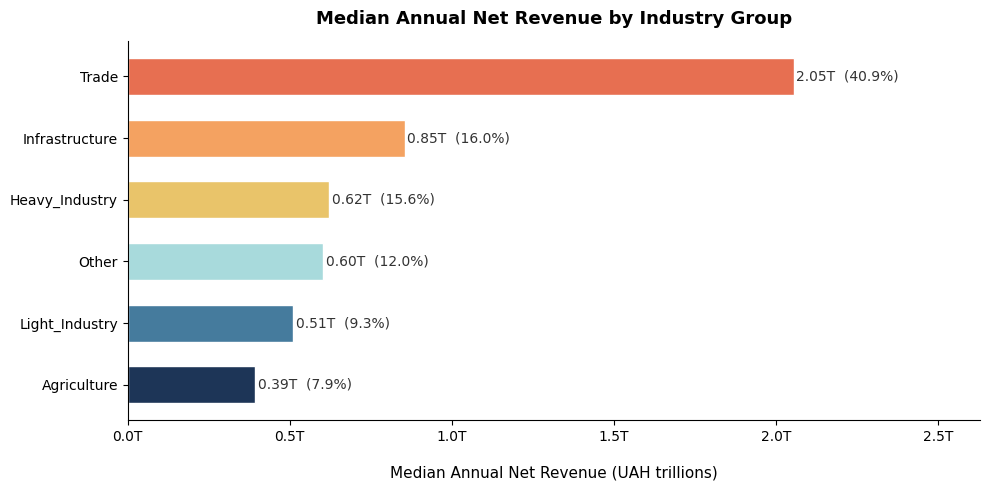

In [20]:
COLOR_MAP = {
    'Trade': '#e76f51', 'Infrastructure': '#f4a261',
    'Light_Industry': '#457b9d', 'Heavy_Industry': '#e9c46a',
    'Other': '#a8dadc', 'Agriculture': '#1d3557',
}
INDUSTRIES = sorted(df_clean['Industry_Group'].dropna().unique())

# Median annual revenue per industry group for bar chart
industry_revenue = (
    df_clean.groupby(['Industry_Group', 'Year'])['Net Revenue']
    .sum().reset_index()
    .groupby('Industry_Group')['Net Revenue'].median()
)
industry_plot = industry_revenue.to_frame(name='Median_Revenue')
industry_plot['Revenue_Share'] = result['Revenue Share (%)']
industry_plot = industry_plot.sort_values('Median_Revenue', ascending=True)

colors = ['#1d3557', '#457b9d', '#a8dadc', '#e9c46a', '#f4a261', '#e76f51']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(industry_plot.index, industry_plot['Median_Revenue'],
               color=colors, edgecolor='white', height=0.6)
for bar, (_, row) in zip(bars, industry_plot.iterrows()):
    ax.text(
        row['Median_Revenue'] + industry_plot['Median_Revenue'].max() * 0.004,
        bar.get_y() + bar.get_height() / 2,
        f"{row['Median_Revenue']/1e9:.2f}T  ({row['Revenue_Share']:.1f}%)",
        va='center', ha='left', fontsize=10, color='#333333'
    )
ax.set_xlabel('Median Annual Net Revenue (UAH trillions)', fontsize=11, labelpad=15)
ax.set_title('Median Annual Net Revenue by Industry Group', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, industry_revenue.max() * 1.28)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}T'))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.grid(False)
plt.tight_layout()
plt.show()

### 5.5 Industry revenue share dynamics by year

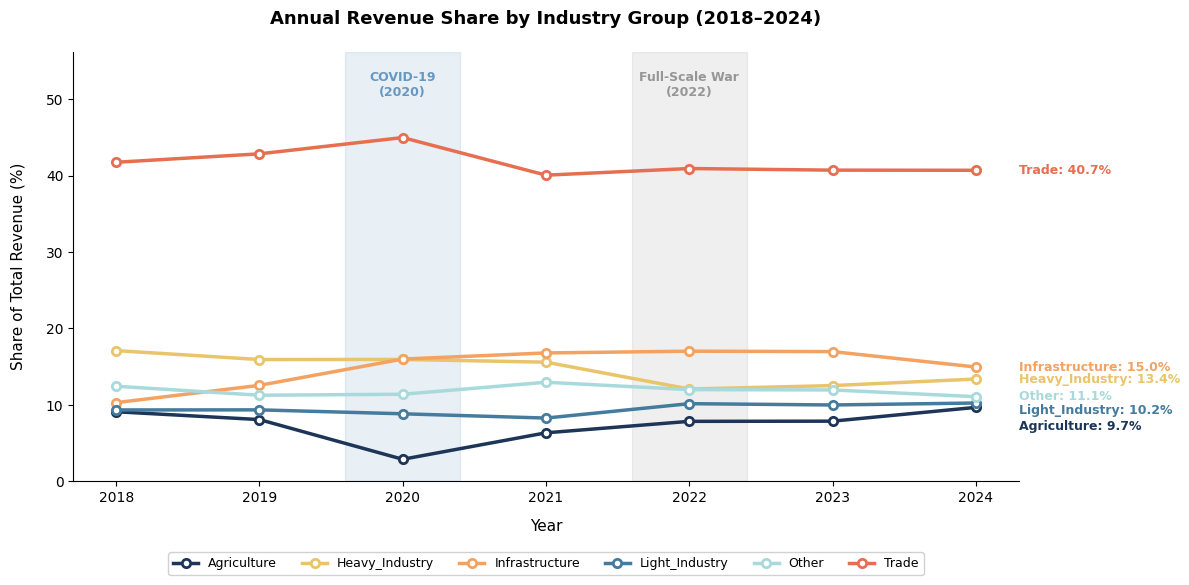

In [21]:
# Revenue share per industry per year
industry_revenue_year = (
    df_clean.groupby(['Year', 'Industry_Group'])['Net Revenue']
    .sum().reset_index()
)
industry_revenue_year['Share'] = (
    industry_revenue_year.groupby('Year')['Net Revenue']
    .transform(lambda x: x / x.sum() * 100)
)
years_list = sorted(industry_revenue_year['Year'].unique())

# Label offsets to prevent overlap at the right edge
offsets = {
    'Trade': 0.0, 'Infrastructure': 0.0, 'Light_Industry': -1.0,
    'Heavy_Industry': 0.0, 'Other': 0.0, 'Agriculture': -2.5,
}
ymax = industry_revenue_year['Share'].max()

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_ylim(0, ymax * 1.25)

for industry in INDUSTRIES:
    data = industry_revenue_year[industry_revenue_year['Industry_Group'] == industry].sort_values('Year')
    ax.plot(
        data['Year'].astype(str), data['Share'],
        color=COLOR_MAP[industry], linewidth=2.5,
        marker='o', markersize=6,
        markerfacecolor='white', markeredgecolor=COLOR_MAP[industry], markeredgewidth=2,
        label=industry
    )
    real_val  = data['Share'].values[-1]
    label_pos = real_val + offsets.get(industry, 0)
    ax.text(len(years_list) - 0.7, label_pos, f'{industry}: {real_val:.1f}%',
            va='center', ha='left', fontsize=9, color=COLOR_MAP[industry], fontweight='bold')

# Highlight crisis periods
ax.axvspan(1.6, 2.4, alpha=0.12, color='steelblue')
ax.axvspan(3.6, 4.4, alpha=0.12, color='gray')
ax.text(2, ymax * 1.12, 'COVID-19\n(2020)', ha='center', fontsize=9,
        color='steelblue', fontweight='bold', alpha=0.8)
ax.text(4, ymax * 1.12, 'Full-Scale War\n(2022)', ha='center', fontsize=9,
        color='gray', fontweight='bold', alpha=0.8)

ax.set_title('Annual Revenue Share by Industry Group (2018–2024)', fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10)
ax.set_ylabel('Share of Total Revenue (%)', fontsize=11, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=9, ncol=6, framealpha=0.9)
ax.grid(False)
plt.tight_layout()
plt.show()

## **6. Variable Construction**
Compute financial ratios. All ratios use a safe denominator check (`np.where`) to avoid division by zero.

In [22]:
def safe_ratio(num_col, denom_col, df, denom_positive=True):
    """Return num/denom where denom > 0, else NaN."""
    condition = df[denom_col] > 0 if denom_positive else df[denom_col] != 0
    return np.where(condition, df[num_col] / df[denom_col], np.nan)

# ── Profitability ──
df_clean['ROA']          = safe_ratio('Net Income', 'Total Assets', df_clean)
df_clean['EBIT_Assets']  = safe_ratio('EBIT', 'Total Assets', df_clean)
df_clean['Gross_Margin'] = safe_ratio('Gross Profit', 'Net Revenue', df_clean)

# ── Liquidity ──
df_clean['WC_Assets'] = np.where(
    df_clean['Total Assets'] > 0,
    (df_clean['Total Current Assets'] - df_clean['Total Current Liabilities']) / df_clean['Total Assets'],
    np.nan
)
df_clean['Current_Ratio'] = safe_ratio('Total Current Assets', 'Total Current Liabilities', df_clean)
df_clean['Quick_Ratio']   = np.where(
    df_clean['Total Current Liabilities'] > 0,
    (df_clean['Total Current Assets'] - df_clean['Inventories']) / df_clean['Total Current Liabilities'],
    np.nan
)

# ── Leverage ──
df_clean['TL_Assets']      = safe_ratio('Total Liabilities', 'Total Assets', df_clean)
df_clean['LT_Liab_Assets'] = safe_ratio('Total Long-term Liabilities', 'Total Assets', df_clean)
df_clean['ST_Liab_Assets'] = safe_ratio('Total Current Liabilities', 'Total Assets', df_clean)
df_clean['AP_Assets']      = safe_ratio('Accounts Payable', 'Total Assets', df_clean)
df_clean['Has_Debt']       = (df_clean['Total Debt'] > 0).astype(int)

# ── Solvency ──
df_clean['IC_Ratio'] = safe_ratio('EBIT', 'Financial Expenses', df_clean)

# ── Activity ──
df_clean['Asset_Turnover']    = safe_ratio('Net Revenue', 'Total Assets', df_clean)
df_clean['Payables_Turnover'] = safe_ratio('COGS', 'Accounts Payable', df_clean)

# ── Investment opportunities — requires one-period lag of PPE ──
df_clean['PPE_prev'] = df_clean.groupby('Firm ID')['PPE'].shift(1)
df_clean['Investment_Opportunities'] = np.where(
    df_clean['PPE_prev'] > 0,
    (df_clean['PPE'] - df_clean['PPE_prev'] + df_clean['Depreciation']) / df_clean['PPE_prev'],
    np.nan
)
df_clean = df_clean.drop(columns=['PPE_prev'])

# ── Size ──
df_clean['Log_Assets'] = np.where(df_clean['Total Assets'] > 0, np.log(df_clean['Total Assets']), np.nan)

INDICATORS = [
    'ROA', 'EBIT_Assets', 'Gross_Margin',
    'WC_Assets', 'Current_Ratio', 'Quick_Ratio',
    'TL_Assets', 'LT_Liab_Assets', 'ST_Liab_Assets', 'AP_Assets', 'Has_Debt',
    'IC_Ratio', 'Asset_Turnover', 'Payables_Turnover',
    'Investment_Opportunities', 'Log_Assets', 'Firm Age',
]
INDICATORS = [v for v in INDICATORS if v in df_clean.columns]

print("=" * 55)
print("FINANCIAL INDICATORS")
print("=" * 55)
print(f"{'Indicator':<25} {'N present':>10}  {'% present':>10}  {'N missing':>10}")
print()
for col in INDICATORS:
    n_p = df_clean[col].notna().sum()
    n_m = df_clean[col].isna().sum()
    print(f"{col:<25} {n_p:>10,}  {n_p/len(df_clean)*100:>9.1f}%  {n_m:>10,}")

FINANCIAL INDICATORS
Indicator                  N present   % present   N missing

ROA                           81,256      100.0%          13
EBIT_Assets                   81,255      100.0%          14
Gross_Margin                  69,496       85.5%      11,773
WC_Assets                     81,266      100.0%           3
Current_Ratio                 79,754       98.1%       1,515
Quick_Ratio                   79,754       98.1%       1,515
TL_Assets                     81,266      100.0%           3
LT_Liab_Assets                81,267      100.0%           2
ST_Liab_Assets                81,266      100.0%           3
AP_Assets                     81,266      100.0%           3
Has_Debt                      81,269      100.0%           0
IC_Ratio                      32,550       40.1%      48,719
Asset_Turnover                81,220       99.9%          49
Payables_Turnover             70,600       86.9%      10,669
Investment_Opportunities      53,859       66.3%      27,410
Lo

## **7. Winsorization**
Trim extreme observations to limit outlier influence. Main ratios use P1/P99; highly skewed ratios (Current Ratio, Quick Ratio, IC Ratio, Payables Turnover) use P5/P95.

### 7.1 Descriptive statistics before winsorization

In [23]:
DESC_VARS = [
    'ROA', 'EBIT_Assets', 'Gross_Margin',
    'WC_Assets', 'Current_Ratio', 'Quick_Ratio',
    'TL_Assets', 'ST_Liab_Assets', 'LT_Liab_Assets', 'AP_Assets',
    'IC_Ratio', 'Asset_Turnover', 'Payables_Turnover',
    'Investment_Opportunities', 'Log_Assets', 'Firm Age',
]
DESC_VARS = [v for v in DESC_VARS if v in df_clean.columns]

def descriptive_stats(df, vars_list):
    """Return a descriptive statistics DataFrame for a list of variables."""
    rows = []
    for var in vars_list:
        s = df[var].dropna()
        rows.append({'Variable': var, 'N': len(s), 'Mean': s.mean(), 'Median': s.median(),
                     'Std': s.std(), 'Min': s.min(), 'Max': s.max(),
                     'Skewness': s.skew(), 'Kurtosis': s.kurtosis()})
    return pd.DataFrame(rows).set_index('Variable')

desc_before = descriptive_stats(df_clean, DESC_VARS)
print("=" * 55)
print("DESCRIPTIVE STATISTICS BEFORE WINSORIZATION")
print("=" * 55)
print(desc_before.to_string(float_format='{:.2f}'.format, col_space=12))

DESCRIPTIVE STATISTICS BEFORE WINSORIZATION
                                    N         Mean       Median          Std          Min          Max     Skewness     Kurtosis
Variable                                                                                                                        
ROA                             81256        -0.31         0.02       119.16    -21521.77     19701.00       -30.12     23705.11
EBIT_Assets                     81255         1.34         0.02       215.23    -10170.25     41387.45       142.18     24451.13
Gross_Margin                    69496        -1.03         0.19        94.39    -17449.00       452.68      -133.17     20863.39
WC_Assets                       81266        -1.72         0.19       183.49    -36903.45         1.00      -165.91     29367.69
Current_Ratio                   79754       143.69         1.56      2976.94         0.00    517236.00       107.96     16003.49
Quick_Ratio                     79754       137.84   

### 7.2 Apply P1/P99 winsorization

In [24]:
WINS_P1_P99 = [
    'ROA', 'EBIT_Assets', 'Gross_Margin',
    'WC_Assets', 'Current_Ratio', 'Quick_Ratio',
    'TL_Assets', 'ST_Liab_Assets', 'LT_Liab_Assets', 'AP_Assets',
    'IC_Ratio', 'Asset_Turnover', 'Payables_Turnover',
    'Investment_Opportunities',
]
WINS_P1_P99 = [v for v in WINS_P1_P99 if v in df_clean.columns]

# Save originals for P5/P95 second pass
for var in WINS_P1_P99:
    df_clean[f'{var}_orig'] = df_clean[var].copy()

for var in WINS_P1_P99:
    p1  = df_clean[f'{var}_orig'].quantile(0.01)
    p99 = df_clean[f'{var}_orig'].quantile(0.99)
    df_clean[var] = df_clean[f'{var}_orig'].clip(p1, p99)

desc_p1p99 = descriptive_stats(df_clean, DESC_VARS)
print("=" * 55)
print("DESCRIPTIVE STATISTICS AFTER WINSORIZATION P1/P99")
print("=" * 55)
print(desc_p1p99.to_string(float_format='{:.2f}'.format, col_space=12))

DESCRIPTIVE STATISTICS AFTER WINSORIZATION P1/P99
                                    N         Mean       Median          Std          Min          Max     Skewness     Kurtosis
Variable                                                                                                                        
ROA                             81256         0.01         0.02         0.27        -1.73         0.75        -3.24        19.12
EBIT_Assets                     81255         0.02         0.02         0.27        -1.64         0.81        -2.81        16.55
Gross_Margin                    69496         0.20         0.19         0.68        -5.01         1.00        -5.13        35.81
WC_Assets                       81266         0.08         0.19         0.95        -6.44         1.00        -4.44        25.45
Current_Ratio                   79754        55.40         1.56       297.51         0.02      2510.07         7.17        52.91
Quick_Ratio                     79754        51

### 7.3 Apply P5/P95 for highly skewed ratios

In [25]:
# These four variables are further trimmed at P5/P95 due to extreme skewness
WINS_P5_P95 = ['Current_Ratio', 'Quick_Ratio', 'IC_Ratio', 'Payables_Turnover']

for var in WINS_P5_P95:
    if var in df_clean.columns and f'{var}_orig' in df_clean.columns:
        p5  = df_clean[f'{var}_orig'].quantile(0.05)
        p95 = df_clean[f'{var}_orig'].quantile(0.95)
        df_clean[var] = df_clean[f'{var}_orig'].clip(p5, p95)

# Drop all _orig columns
orig_cols = [f'{var}_orig' for var in WINS_P1_P99 if f'{var}_orig' in df_clean.columns]
df_clean  = df_clean.drop(columns=orig_cols)

desc_final = descriptive_stats(df_clean, DESC_VARS)
print("=" * 70)
print("DESCRIPTIVE STATISTICS FINAL (P1/P99 and P5/P95)")
print("=" * 70)
print(desc_final.to_string(float_format='{:.2f}'.format, col_space=12))

DESCRIPTIVE STATISTICS FINAL (P1/P99 and P5/P95)
                                    N         Mean       Median          Std          Min          Max     Skewness     Kurtosis
Variable                                                                                                                        
ROA                             81256         0.01         0.02         0.27        -1.73         0.75        -3.24        19.12
EBIT_Assets                     81255         0.02         0.02         0.27        -1.64         0.81        -2.81        16.55
Gross_Margin                    69496         0.20         0.19         0.68        -5.01         1.00        -5.13        35.81
WC_Assets                       81266         0.08         0.19         0.95        -6.44         1.00        -4.44        25.45
Current_Ratio                   79754        12.08         1.56        29.87         0.18       125.96         3.17         8.78
Quick_Ratio                     79754         9.

## **8. Financial Distress Proxy**

### 8.1 Revenue growth before winsorization

In [26]:
# Revenue growth requires lagged Net Revenue — only available from 2019 onward
df_clean = df_clean.sort_values(['Firm ID', 'Year'])
df_clean['Rev_prev'] = df_clean.groupby('Firm ID')['Net Revenue'].shift(1)

df_clean['Revenue_Growth'] = np.where(
    (df_clean['Rev_prev'] > 0) & (df_clean['Net Revenue'] > 0),
    (df_clean['Net Revenue'] - df_clean['Rev_prev']) / df_clean['Rev_prev'],
    np.nan
)
df_clean = df_clean.drop(columns=['Rev_prev'])

def desc_single(series, name):
    """Single-variable descriptive statistics."""
    s = series.dropna()
    return pd.DataFrame([{'Variable': name, 'N': len(s), 'Mean': s.mean(), 'Median': s.median(),
                           'Std': s.std(), 'Min': s.min(), 'Max': s.max(),
                           'Skewness': s.skew(), 'Kurtosis': s.kurtosis()}]).set_index('Variable')

print("=" * 65)
print("REVENUE GROWTH DESCRIPTIVE STATISTICS (BEFORE WINSORIZATION)")
print("=" * 65)
print(desc_single(df_clean['Revenue_Growth'], 'Revenue_Growth')
      .to_string(float_format='{:.2f}'.format, col_space=12))

REVENUE GROWTH DESCRIPTIVE STATISTICS (BEFORE WINSORIZATION)
                          N         Mean       Median          Std          Min          Max     Skewness     Kurtosis
Variable                                                                                                              
Revenue_Growth        53034        33.38         0.08      3934.23        -1.00    867743.97       205.12     44728.33


### 8.2 Revenue growth after winsorization P5/P95

In [27]:
p5  = df_clean['Revenue_Growth'].quantile(0.05)
p95 = df_clean['Revenue_Growth'].quantile(0.95)
n_clipped = ((df_clean['Revenue_Growth'] < p5) | (df_clean['Revenue_Growth'] > p95)).sum()
df_clean['Revenue_Growth'] = df_clean['Revenue_Growth'].clip(p5, p95)

print("=" * 65)
print("REVENUE GROWTH DESCRIPTIVE STATISTICS (AFTER WINSORIZATION P5/P95)")
print("=" * 65)
print(desc_single(df_clean['Revenue_Growth'], 'Revenue_Growth')
      .to_string(float_format='{:.2f}'.format, col_space=12))

REVENUE GROWTH DESCRIPTIVE STATISTICS (AFTER WINSORIZATION P5/P95)
                          N         Mean       Median          Std          Min          Max     Skewness     Kurtosis
Variable                                                                                                              
Revenue_Growth        53034         0.16         0.08         0.58        -0.73         1.76         1.09         1.39


### 8.3 Revenue growth by industry and year

In [28]:
pivot = (
    df_clean[df_clean['Year'] >= 2019]
    .groupby(['Industry_Group', 'Year'])['Revenue_Growth']
    .mean().mul(100).round(1).unstack('Year')
)
pivot['Overall Mean'] = pivot.mean(axis=1).round(1)

def style_growth_table(df):
    return (
        df.style
        .format('{:.1f}%', na_rep='—')
        .background_gradient(cmap='RdYlGn', axis=None, vmin=-30, vmax=50, subset=df.columns[:-1])
        .background_gradient(cmap='RdYlGn', axis=None, vmin=-30, vmax=50, subset=['Overall Mean'])
        .set_properties(**{'font-size': '11px', 'text-align': 'center',
                           'border': '1px solid #e0e0e0', 'padding': '6px 10px'})
        .set_properties(subset=pd.IndexSlice[:, ['Overall Mean']],
                        **{'font-weight': 'bold', 'border-left': '2px solid #555'})
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'),
                                          ('font-size', '11px'), ('text-align', 'center'),
                                          ('padding', '8px 10px')]},
            {'selector': 'tr:hover', 'props': [('background-color', '#f5f5f5')]},
        ])
        .set_caption('Average Revenue Growth (%) by Industry Group and Year')
    )

display(style_growth_table(pivot))

Year,2019,2020,2021,2022,2023,2024,Overall Mean
Industry_Group,,,,,,,
Agriculture,7.8%,5.5%,45.6%,-4.2%,29.1%,31.1%,19.2%
Heavy_Industry,2.7%,1.0%,34.6%,-15.9%,37.5%,22.2%,13.7%
Infrastructure,13.6%,0.3%,24.5%,-8.9%,24.9%,19.8%,12.4%
Light_Industry,2.6%,3.8%,18.4%,9.8%,22.8%,13.2%,11.8%
Other,23.2%,11.6%,31.6%,-1.2%,31.3%,26.9%,20.6%
Trade,8.3%,1.8%,27.5%,-8.3%,33.2%,15.9%,13.1%


### 8.4 Construct distress criteria and composite indicator

In [29]:
# ── Criterion 1: EBITDA < 0 ──
df_clean['Distress_EBITDA'] = np.where(
    df_clean['EBITDA'].notna(), (df_clean['EBITDA'] < 0).astype(int), np.nan
)

# ── Criterion 2: Total Equity < 0 ──
df_clean['Distress_Equity'] = np.where(
    df_clean['Total Equity'].notna(), (df_clean['Total Equity'] < 0).astype(int), np.nan
)

# ── Criterion 3: Revenue decline below 0.5 std of industry-year mean ──
industry_year_stats = (
    df_clean[(df_clean['Year'] >= 2019) & df_clean['Revenue_Growth'].notna()]
    .groupby(['Industry_Group', 'Year'])['Revenue_Growth']
    .agg(mean='mean', std='std').reset_index()
)
industry_year_stats['threshold'] = industry_year_stats['mean'] - 0.5 * industry_year_stats['std']

df_clean = df_clean.merge(
    industry_year_stats[['Industry_Group', 'Year', 'threshold']],
    on=['Industry_Group', 'Year'], how='left'
)
df_clean['Distress_Revenue_Growth'] = np.where(
    df_clean['Revenue_Growth'].notna(),
    ((df_clean['Revenue_Growth'] < 0) & (df_clean['Revenue_Growth'] < df_clean['threshold'])).astype(int),
    np.nan
)
df_clean = df_clean.drop(columns=['threshold'])

# ── Composite: >= 2 of 3 criteria, applied to 2019–2024 only ──
df_clean['Distress_Score'] = np.where(
    df_clean['Year'] >= 2019,
    df_clean[['Distress_EBITDA', 'Distress_Revenue_Growth', 'Distress_Equity']].sum(axis=1, min_count=1),
    np.nan
)
df_clean['Financial_Distress'] = np.where(
    df_clean['Distress_Score'].notna(), (df_clean['Distress_Score'] >= 2).astype(int), np.nan
)

# Build analytical sample
ana = df_clean[df_clean['Financial_Distress'].notna()].copy()

print("CRITERIA INCIDENCE (2019–2024)")
print("=" * 55)
print(f"  Observations  : {len(ana):,}")
print(f"  Unique firms  : {ana['Firm ID'].nunique():,}")
print()
print(f"  Distress_EBITDA          = 1 : "
      f"{(ana['Distress_EBITDA'] == 1).sum():,}  "
      f"({(ana['Distress_EBITDA'] == 1).mean() * 100:.1f}%)")
print(f"  Distress_Equity          = 1 : "
      f"{(ana['Distress_Equity'] == 1).sum():,}  "
      f"({(ana['Distress_Equity'] == 1).mean() * 100:.1f}%)")
print(f"  Distress_Revenue_Growth  = 1 : "
      f"{(ana['Distress_Revenue_Growth'] == 1).sum():,}  "
      f"({(ana['Distress_Revenue_Growth'] == 1).mean() * 100:.1f}%)")
print()
print("COMPOSITE FINANCIAL DISTRESS (>= 2 of 3)")
print("=" * 55)
print(f"  Distress (1) : {(ana['Financial_Distress'] == 1).sum():,}  "
      f"({(ana['Financial_Distress'] == 1).mean() * 100:.1f}%)")
print(f"  Healthy  (0) : {(ana['Financial_Distress'] == 0).sum():,}  "
      f"({(ana['Financial_Distress'] == 0).mean() * 100:.1f}%)")
print()
print("BY YEAR:")
print(ana.groupby('Year')['Financial_Distress']
      .agg(N_distress=lambda x: (x == 1).sum(), N_total='count',
           Distress_pct=lambda x: (x == 1).mean() * 100)
      .round(1).to_string())
print()
print("BY INDUSTRY:")
print(ana.groupby('Industry_Group')['Financial_Distress']
      .agg(N_distress=lambda x: (x == 1).sum(), N_total='count',
           Distress_pct=lambda x: (x == 1).mean() * 100)
      .round(1).sort_values('Distress_pct', ascending=False).to_string())

CRITERIA INCIDENCE (2019–2024)
  Observations  : 70,351
  Unique firms  : 18,183

  Distress_EBITDA          = 1 : 19,850  (28.2%)
  Distress_Equity          = 1 : 8,976  (12.8%)
  Distress_Revenue_Growth  = 1 : 14,095  (20.0%)

COMPOSITE FINANCIAL DISTRESS (>= 2 of 3)
  Distress (1) : 9,670  (13.7%)
  Healthy  (0) : 60,681  (86.3%)

BY YEAR:
      N_distress  N_total  Distress_pct
Year                                   
2019        1661    12528          13.3
2020        1667    10673          15.6
2021        1458    12635          11.5
2022        1944    12117          16.0
2023        1622    11900          13.6
2024        1318    10498          12.6

BY INDUSTRY:
                N_distress  N_total  Distress_pct
Industry_Group                                   
Infrastructure        1698     7185          23.6
Heavy_Industry        1607     8209          19.6
Light_Industry         763     5499          13.9
Trade                 1382    10676          12.9
Other                

## **9. Criteria Independence (Phi-Coefficient)**
Validate that the three criteria capture different dimensions of financial health. Values below 0.4 confirm acceptable independence for a composite proxy.

In [30]:
def phi_coefficient(x, y):
    """Compute phi-coefficient and p-value for two binary variables."""
    ct = pd.crosstab(x, y)
    chi2, p, _, _ = chi2_contingency(ct)
    return np.sqrt(chi2 / ct.values.sum()), p

CRITERIA = {
    'EBITDA<0' : 'Distress_EBITDA',
    'Rev↓'     : 'Distress_Revenue_Growth',
    'Equity<0' : 'Distress_Equity',
}

# Keep only rows where all three criteria are available
mask = ana[list(CRITERIA.values())].notna().all(axis=1)
tmp  = ana[mask].copy()

print("CRITERIA INDEPENDENCE φ-COEFFICIENT")
print("=" * 60)
print(f"{'Pair':<40} {'φ':>8}  {'p-value':>10}  {'Interpretation':>15}")
print("-" * 60)
for (name_a, col_a), (name_b, col_b) in itertools.combinations(CRITERIA.items(), 2):
    phi, p = phi_coefficient(tmp[col_a], tmp[col_b])
    interp = '✓ weak' if phi < 0.2 else ('⚠ moderate' if phi < 0.4 else '✗ strong')
    pair = f"{name_a}  vs  {name_b}"
    print(f"{pair:<40} {phi:>8.3f}  {p:>10.4f}  {interp:>15}")
print()
print("Interpretation:")
print("  φ < 0.20  → weak correlation   → criteria are sufficiently independent")
print("  φ < 0.40  → moderate           → acceptable for composite proxy")
print("  φ ≥ 0.40  → strong             → criteria overlap significantly")

CRITERIA INDEPENDENCE φ-COEFFICIENT
Pair                                            φ     p-value   Interpretation
------------------------------------------------------------
EBITDA<0  vs  Rev↓                          0.228      0.0000       ⚠ moderate
EBITDA<0  vs  Equity<0                      0.317      0.0000       ⚠ moderate
Rev↓  vs  Equity<0                          0.102      0.0000           ✓ weak

Interpretation:
  φ < 0.20  → weak correlation   → criteria are sufficiently independent
  φ < 0.40  → moderate           → acceptable for composite proxy
  φ ≥ 0.40  → strong             → criteria overlap significantly


## **10. Save**
Save cleaned datasets and metadata for use in notebooks 02 and 03.

In [31]:
import os
os.makedirs('data', exist_ok=True)

df_clean.to_csv('data/df_clean.csv', index=False)
ana.to_csv('data/ana.csv', index=False)

print(f"Saved df_clean : {len(df_clean):,} obs | {df_clean.shape[1]} columns")
print(f"Saved ana      : {len(ana):,} obs | distress rate: {ana['Financial_Distress'].mean()*100:.1f}%")

Saved df_clean : 81,269 obs | 192 columns
Saved ana      : 70,351 obs | distress rate: 13.7%
